# Hybrid Spatial Recurrent Transformer for Chess

## Architecture: Spatial Board Encoding + From/To Heads + Recurrent Shared Weights

This notebook trains a **custom transformer from scratch** to predict chess moves using **From/To prediction heads** on a spatially-encoded board.

### Neuroscience Motivation

The architecture is inspired by two findings from computational neuroscience:

1. **CORnet-s** (Kubilius et al., 2019): A 4-layer *recurrent* neural network that matches 100+ layer feedforward networks on ImageNet and achieves the highest Brain-Score. Recurrence allows shallow networks to match deep ones by processing the same representation multiple times.

2. **BLT Networks** (Spoerer et al., 2017): Bottom-up, Lateral, and Top-down connections improve performance on challenging visual recognition tasks. Lateral connections enable within-layer communication.

### Mapping to Transformers

| Neuroscience Concept | Transformer Equivalent |
|---|---|
| Lateral connections (BLT "L") | Self-attention within each layer |
| Recurrence (CORnet-s) | Shared transformer block applied K times |
| Time-cycle disambiguation | Learned iteration embeddings |
| Deep feedforward network | K iterations with 1 shared block ≈ K unique layers |

### Hybrid design (inspired by sgrvinod/chess-transformers)

- **Separate embedding tables** per token type: pieces (14 IDs, incl. light/dark empty), turn (2), castling (2, shared), en passant (9)
- **From/To prediction heads**: each board square token is scored as source or destination (64+64 outputs instead of 4,272-class classification)
- **Learned positional embeddings** over the 70-token sequence
- At inference, each legal move is scored as `from_logits[from_sq] + to_logits[to_sq]`

In [ ]:
# ── Setup (run once on Colab) ──────────────────────────────────────────────
!git clone https://github.com/GabrielSC92/Transformers_Midterm.git 2>/dev/null; \
    cp Transformers_Midterm/model.py . 2>/dev/null || true
!pip install -q torch python-chess datasets huggingface_hub tqdm matplotlib

In [1]:
import json
import math
import os
import random
import time
from collections import Counter
from pathlib import Path

import chess
import chess.pgn
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from tqdm.auto import tqdm

from model import (
    BoardTokenizer,
    RecurrentTransformer,
    SQUARE_NAMES,
    MOVE_VOCAB,
    MOVE_TO_IDX,
    NUM_MOVES,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## 1. Data Pipeline

We load chess games from the `angeluriot/chess_games` dataset, filter for games where both players are rated ≥ 1500 ELO, replay each game to extract `(FEN, UCI move)` pairs, and build a classification dataset.

In [ ]:
# ── Load dataset ───────────────────────────────────────────────────────────
ds = load_dataset("angeluriot/chess_games", split="train", streaming=True)

In [2]:
# ── Load (FEN, UCI) pairs ───────────────────────────────────────────────────
# Option A: from engine_data.jsonl (Stockfish best-move data) — recommended
# Option B: from dataset (human games, streamed)

ENGINE_DATA_FILE = "engine_data.jsonl"  # from generate_engine_data.py

if Path(ENGINE_DATA_FILE).exists():
    positions = []
    with open(ENGINE_DATA_FILE) as f:
        for line in f:
            d = json.loads(line)
            if d["uci"] in MOVE_TO_IDX:
                positions.append((d["fen"], d["uci"]))
    print(f"Loaded {len(positions)} (FEN, UCI) pairs from {ENGINE_DATA_FILE}")
else:
    # Fallback: stream from dataset (human games)
    MIN_ELO = 1500
    TARGET_POSITIONS = 750_000
    positions = []
    games_processed = 0
    for row in tqdm(ds, desc="Processing games", total=None):
        if len(positions) >= TARGET_POSITIONS:
            break
        white_elo = row.get("white_elo")
        black_elo = row.get("black_elo")
        try:
            white_elo = int(white_elo) if white_elo is not None else 0
            black_elo = int(black_elo) if black_elo is not None else 0
        except (ValueError, TypeError):
            continue
        if white_elo < MIN_ELO or black_elo < MIN_ELO:
            continue
        uci_moves = row.get("moves_uci")
        if not uci_moves:
            continue
        board = chess.Board()
        for uci_str in uci_moves:
            fen = board.fen()
            try:
                move = chess.Move.from_uci(uci_str)
                if move not in board.legal_moves:
                    break
            except (ValueError, chess.InvalidMoveError):
                break
            if uci_str in MOVE_TO_IDX:
                positions.append((fen, uci_str))
            board.push(move)
        games_processed += 1
    print(f"Streamed {len(positions)} positions from dataset")

print(f"Total positions: {len(positions)}")

Loaded 500000 (FEN, UCI, score_cp) triples from engine_data_v2.jsonl
Total positions: 500000


In [3]:
# ── Train / validation split ──────────────────────────────────────────────

random.seed(42)
random.shuffle(positions)

val_size = min(10_000, len(positions) // 20)
train_positions = positions[val_size:]
val_positions = positions[:val_size]

print(f"Train: {len(train_positions)}, Val: {len(val_positions)}")

Train: 490000, Val: 10000


## 2. Dataset & DataLoader

In [4]:
tokenizer = BoardTokenizer()

# Map square names to indices (python-chess order: a1=0 .. h8=63)
SQ_NAME_TO_IDX = {name: i for i, name in enumerate(SQUARE_NAMES)}


class ChessMoveDataset(Dataset):
    """Returns a dict of board tensors + from/to square labels."""

    def __init__(self, data, tokenizer):
        self.data = data
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        fen, uci = self.data[idx]
        enc = self.tokenizer.encode(fen)

        from_sq = SQ_NAME_TO_IDX[uci[:2]]
        to_sq = SQ_NAME_TO_IDX[uci[2:4]]

        return {
            "board": torch.tensor(enc["board"], dtype=torch.long),
            "turn": torch.tensor(enc["turn"], dtype=torch.long),
            "castling": torch.tensor(enc["castling"], dtype=torch.long),
            "ep": torch.tensor(enc["ep"], dtype=torch.long),
            "from_sq": from_sq,
            "to_sq": to_sq,
        }


train_ds = ChessMoveDataset(train_positions, tokenizer)
val_ds = ChessMoveDataset(val_positions, tokenizer)

BATCH_SIZE = 512
GRAD_ACCUM_STEPS = 1

NUM_WORKERS = 0 if ("google.colab" in __import__("sys").modules or __import__("sys").platform == "win32") else 4
PIN_MEMORY = torch.cuda.is_available()
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 957, Val batches: 20


## 3. Model

```
FEN → BoardTokenizer → {board(64), turn(1), castling(4), ep(1)}
    → Separate Embeddings + Learned Positional Embeddings
    → Shared Transformer Block × K iterations (with iteration embeddings)
    → Board tokens → From Head (64 scores) + To Head (64 scores)
```

In [5]:
model = RecurrentTransformer(
    d_model=512,
    nhead=8,
    d_ff=2048,
    num_iterations=8,
    dropout=0.1,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: ~{total_params * 4 / 1e6:.1f} MB (fp32)")

Total parameters: 3,273,987
Trainable parameters: 3,273,987
Model size: ~13.1 MB (fp32)


## 4. Training

In [6]:
NUM_EPOCHS = 8
D_MODEL = 512
WARMUP_STEPS = 4000
LABEL_SMOOTHING = 0.1

optimizer = torch.optim.Adam(
    model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9
)

def vaswani_lr(step):
    step = max(step, 1)
    return D_MODEL ** (-0.5) * min(step ** (-0.5), step * WARMUP_STEPS ** (-1.5))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=vaswani_lr)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

total_steps = NUM_EPOCHS * (len(train_loader) // GRAD_ACCUM_STEPS)
print(f"Total training steps: {total_steps} (optimizer steps, {len(train_loader)} micro-batches/epoch)")

Total training steps: 7656 (optimizer steps, 957 micro-batches/epoch)


In [7]:
#test that torch detects GPU
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")

CUDA available: True
Device: NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [8]:
import plotly.graph_objects as go
from IPython.display import display, clear_output, HTML

history = {"train_loss": [], "val_loss": [], "val_from_acc": [], "val_to_acc": [], "val_move_acc": []}

scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))
autocast_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16


def _batch_to_device(batch, dev):
    return {k: v.to(dev) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    from_correct = to_correct = move_correct = 0
    total = 0
    with torch.no_grad(), torch.amp.autocast(device, dtype=autocast_dtype):
        for batch in loader:
            batch = _batch_to_device(batch, device)
            from_labels = batch.pop("from_sq").to(device)
            to_labels = batch.pop("to_sq").to(device)
            from_logits, to_logits = model(batch)
            loss = criterion(from_logits.float(), from_labels) + criterion(to_logits.float(), to_labels)
            bs = from_labels.size(0)
            total_loss += loss.item() * bs

            from_pred = from_logits.argmax(dim=1)
            to_pred = to_logits.argmax(dim=1)
            from_correct += (from_pred == from_labels).sum().item()
            to_correct += (to_pred == to_labels).sum().item()
            move_correct += ((from_pred == from_labels) & (to_pred == to_labels)).sum().item()
            total += bs

    return total_loss / total, from_correct / total, to_correct / total, move_correct / total


best_val_move = 0.0

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_samples = 0
    t0 = time.time()
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for step_in_epoch, batch in enumerate(pbar):
        batch = _batch_to_device(batch, device)
        from_labels = batch.pop("from_sq").to(device)
        to_labels = batch.pop("to_sq").to(device)

        with torch.amp.autocast(device, dtype=autocast_dtype):
            from_logits, to_logits = model(batch)
            loss = criterion(from_logits.float(), from_labels) + criterion(to_logits.float(), to_labels)
            loss = loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step_in_epoch + 1) % GRAD_ACCUM_STEPS == 0 or (step_in_epoch + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        bs = from_labels.size(0)
        epoch_loss += loss.item() * GRAD_ACCUM_STEPS * bs
        epoch_samples += bs
        pbar.set_postfix(loss=f"{loss.item()*GRAD_ACCUM_STEPS:.4f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")

    train_loss = epoch_loss / epoch_samples
    val_loss, val_from, val_to, val_move = evaluate(model, val_loader)
    elapsed = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_from_acc"].append(val_from)
    history["val_to_acc"].append(val_to)
    history["val_move_acc"].append(val_move)

    epochs_x = list(range(1, len(history["train_loss"]) + 1))
    clear_output(wait=True)
    for i in range(len(epochs_x)):
        suffix = f" ({elapsed:.0f}s)" if i == len(epochs_x) - 1 else ""
        print(
            f"Epoch {epochs_x[i]}: train={history['train_loss'][i]:.4f} "
            f"val={history['val_loss'][i]:.4f} "
            f"from={history['val_from_acc'][i]:.4f} "
            f"to={history['val_to_acc'][i]:.4f} "
            f"move={history['val_move_acc'][i]:.4f}{suffix}"
        )
    fig = go.Figure(layout=go.Layout(title="Training", xaxis_title="Epoch", height=400))
    fig.add_trace(go.Scatter(x=epochs_x, y=history["train_loss"], name="Train loss", mode="lines+markers"))
    fig.add_trace(go.Scatter(x=epochs_x, y=history["val_loss"], name="Val loss", mode="lines+markers"))
    fig.add_trace(go.Scatter(x=epochs_x, y=history["val_from_acc"], name="From acc", mode="lines+markers"))
    fig.add_trace(go.Scatter(x=epochs_x, y=history["val_to_acc"], name="To acc", mode="lines+markers"))
    fig.add_trace(go.Scatter(x=epochs_x, y=history["val_move_acc"], name="Move acc", mode="lines+markers"))
    display(HTML(fig.to_html(include_plotlyjs="cdn")))

    if val_move > best_val_move:
        best_val_move = val_move
        torch.save(model.state_dict(), "best_model.pt")
        print(f"  New best model saved (move acc: {val_move:.4f})")

Epoch 1: train=6.3137 val=5.7184 v_loss=0.0695 from=0.3429 to=0.1920 move=0.0996
Epoch 2: train=5.4160 val=5.1207 v_loss=0.0603 from=0.4145 to=0.2722 move=0.1790
Epoch 3: train=4.9742 val=4.7719 v_loss=0.0557 from=0.4517 to=0.3218 move=0.2335
Epoch 4: train=4.7216 val=4.6024 v_loss=0.0648 from=0.4757 to=0.3472 move=0.2584
Epoch 5: train=4.5607 val=4.4585 v_loss=0.0500 from=0.4920 to=0.3641 move=0.2845
Epoch 6: train=4.4032 val=4.3554 v_loss=0.0478 from=0.5048 to=0.3842 move=0.3053
Epoch 7: train=4.2868 val=4.2622 v_loss=0.0450 from=0.5212 to=0.4014 move=0.3260
Epoch 8: train=4.1944 val=4.1944 v_loss=0.0419 from=0.5265 to=0.4062 move=0.3273 (346s)


  New best model saved (move acc: 0.3273)


## 5. Training Curves

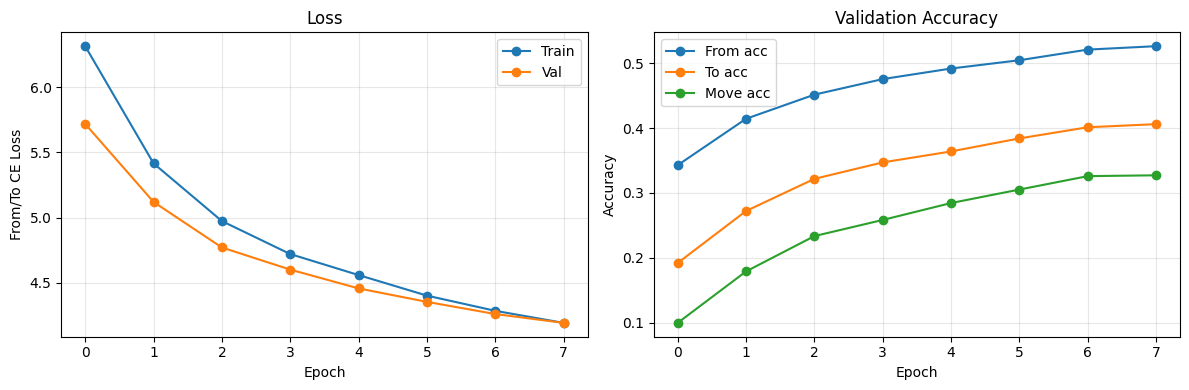

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train", marker="o")
axes[0].plot(history["val_loss"], label="Val", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("From/To CE Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["val_from_acc"], label="From acc", marker="o")
axes[1].plot(history["val_to_acc"], label="To acc", marker="o")
axes[1].plot(history["val_move_acc"], label="Move acc", marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

## 6. Evaluation: Play Test Games

In [1]:
model.load_state_dict(torch.load("best_model.pt", map_location=device, weights_only=True))
model.eval()


@torch.no_grad()
def predict_move(model, tokenizer, fen):
    """Pick the highest-scoring legal move using From/To heads."""
    board = chess.Board(fen)
    legal_moves = list(board.legal_moves)
    if not legal_moves:
        return None

    enc = tokenizer.encode(fen)
    batch = {
        "board": torch.tensor([enc["board"]], dtype=torch.long, device=device),
        "turn": torch.tensor([enc["turn"]], dtype=torch.long, device=device),
        "castling": torch.tensor([enc["castling"]], dtype=torch.long, device=device),
        "ep": torch.tensor([enc["ep"]], dtype=torch.long, device=device),
    }
    from_logits, to_logits = model(batch)
    from_logits = from_logits.squeeze(0)
    to_logits = to_logits.squeeze(0)

    best_score = float("-inf")
    best_uci = None
    for move in legal_moves:
        fsq = move.from_square
        tsq = move.to_square
        score = from_logits[fsq].item() + to_logits[tsq].item()
        if score > best_score:
            best_score = score
            best_uci = move.uci()

    return best_uci


def play_test_game(model, tokenizer, max_moves=500):
    board = chess.Board()
    move_count = 0
    model_color = chess.WHITE

    while not board.is_game_over() and move_count < max_moves:
        if board.turn == model_color:
            uci = predict_move(model, tokenizer, board.fen())
            if uci is None:
                break
            board.push_uci(uci)
        else:
            legal = list(board.legal_moves)
            board.push(random.choice(legal))
        move_count += 1

    return board.result(), move_count


results = Counter()
num_test_games = 200
for i in range(num_test_games):
    result, moves = play_test_game(model, tokenizer)
    results[result] += 1
    if i < 5:
        print(f"  Game {i+1}: {result} in {moves} moves")

print(f"\nResults over {num_test_games} games vs Random:")
for r, c in sorted(results.items()):
    print(f"  {r}: {c} ({100*c/num_test_games:.0f}%)")

NameError: name 'model' is not defined

## 7. Push to HuggingFace

In [ ]:
from huggingface_hub import HfApi, login

login()

REPO_ID = "Izzent/recurrent-transformer-chess"

# Always load best_model.pt before uploading to avoid pushing a stale model
best_state = torch.load("best_model.pt", map_location=device, weights_only=True)
model.load_state_dict(best_state)
model.eval()
print("Loaded best_model.pt for upload")

config = model.get_config()
with open("config.json", "w") as f:
    json.dump(config, f, indent=2)

with open("tokenizer.json", "w") as f:
    json.dump(tokenizer.to_dict(), f, indent=2)

torch.save(model.state_dict(), "model.pt")

api = HfApi()
api.create_repo(REPO_ID, exist_ok=True)

for fname in ["config.json", "tokenizer.json", "model.pt"]:
    api.upload_file(
        path_or_fileobj=fname,
        path_in_repo=fname,
        repo_id=REPO_ID,
    )
    print(f"Uploaded {fname}")

print(f"\nModel uploaded to https://huggingface.co/{REPO_ID}")

## 8. Final Validation with chess_tournament

Run this after installing the chess_exam package to confirm the player works end-to-end.

In [ ]:
# !git clone https://github.com/bylinina/chess_exam.git
# %cd chess_exam
# %pip install -e .
# %cd ..

In [ ]:
# from chess_tournament import Game, RandomPlayer
# from player import TransformerPlayer
#
# tp = TransformerPlayer("RecurrentTransformer")
# rp = RandomPlayer("Random")
#
# results = []
# for i in range(10):
#     game = Game(tp, rp, max_half_moves=200)
#     outcome, scores, fallbacks = game.play()
#     results.append((outcome, scores, fallbacks))
#     print(f"Game {i+1}: {outcome} | Fallbacks: {fallbacks}")
#
# total_fallbacks = sum(r[2].get("RecurrentTransformer", 0) for r in results)
# print(f"\nTotal fallbacks across 10 games: {total_fallbacks}")